# Advanced AI — Comparing Classification Models

**Dataset:** Breast Cancer Wisconsin (Diagnostic)  
**Source:** UCI Machine Learning Repository, loaded through `sklearn.datasets.load_breast_cancer()`  
**Target:** `0 = Malignant`, `1 = Benign`  
**Selected features:** `mean radius` and `mean texture`

This notebook follows the laboratory requirements for comparing:
1. Linear Regression adapted to classification
2. Logistic Regression
3. Support Vector Machine (SVM)

The same train/test split and preprocessing are used for all three models.


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the dataset and select two numerical features

In [30]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

feature1 = 'mean radius'
feature2 = 'mean texture'

X = X[[feature1, feature2]]

print("Dataset: Breast Cancer Wisconsin (Diagnostic)")
print("Source: UCI Machine Learning Repository")
print("Loaded through: sklearn.datasets.load_breast_cancer")
print("Selected features:", feature1, "and", feature2)
print("Target: 0 = Malignant, 1 = Benign")
print("Dimensions:", X.shape)
print("\nClass distribution:")
print(y.value_counts())

Dataset: Breast Cancer Wisconsin (Diagnostic)
Source: UCI Machine Learning Repository
Loaded through: sklearn.datasets.load_breast_cancer
Selected features: mean radius and mean texture
Target: 0 = Malignant, 1 = Benign
Dimensions: (569, 2)

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


## 2. Initial visualization

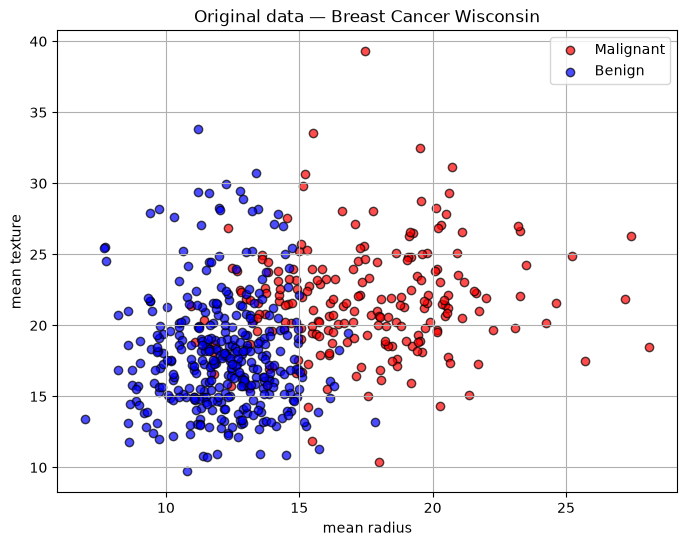

In [31]:
plt.figure(figsize=(8, 6))

colors = {0: 'red', 1: 'blue'}
labels = {0: 'Malignant', 1: 'Benign'}

for cls in [0, 1]:
    mask = y == cls
    plt.scatter(
        X.loc[mask, feature1],
        X.loc[mask, feature2],
        c=colors[cls],
        label=labels[cls],
        alpha=0.7,
        edgecolors='k'
    )

plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('Original data — Breast Cancer Wisconsin')
plt.legend()
plt.grid(True)
plt.show()

## 3. Train/test split and preprocessing

The dataset is divided using the same samples for all three models.  
Feature scaling is fitted only on the training data and then applied to the test data.

### A1. Why should the testing samples not be used during model training or preprocessing?
Because doing so would introduce **data leakage**. The model would indirectly gain information about the test set, producing overly optimistic evaluation metrics.

### A2. Why is it important to use the same train/test split when comparing the three models?
Because the comparison should be fair. If each model were tested on different samples, performance differences could be caused by the data split rather than by the algorithms themselves.


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Testing samples: {X_test_scaled.shape[0]}")

Training samples: 455
Testing samples: 114


## 4. Linear Regression from scratch

The implementation includes:
- Prediction
- Mean Squared Error (MSE)
- Gradient Descent
- Loss history


In [33]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.lr = learning_rate
        self.n_iter = n_iter
        self.weights = None
        self.bias = None
        self.loss_history = []

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def mse(self, X, y):
        y_pred = self.predict(X)
        return np.mean((y_pred - y) ** 2)

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.n_iter):
            y_pred = self.predict(X)
            error = y_pred - y

            # Exact gradient of MSE
            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = self.mse(X, y)
            self.loss_history.append(loss)

        return self

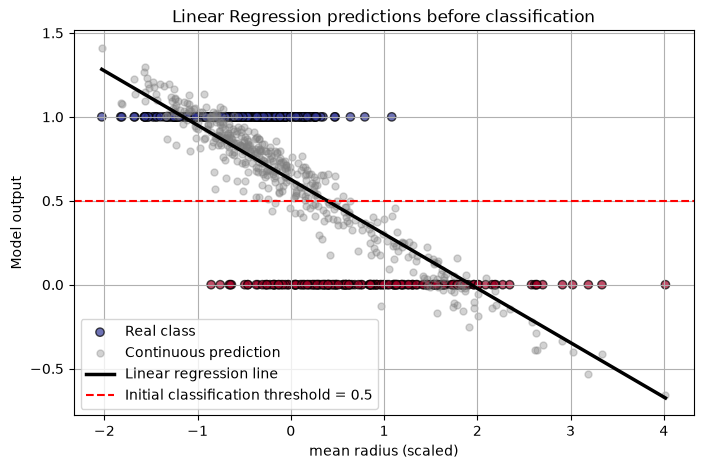

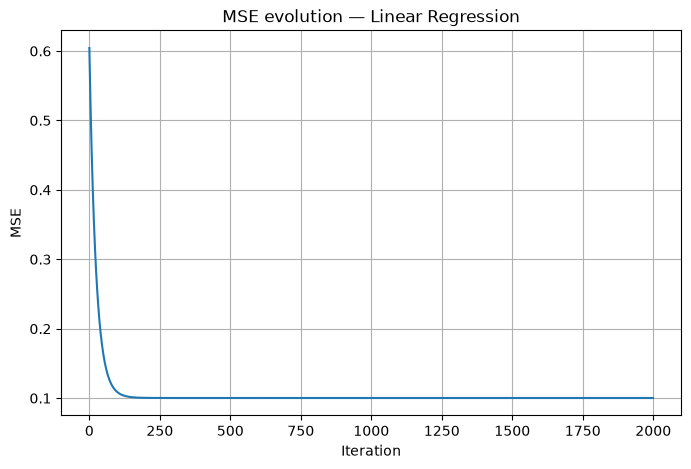

Final training MSE: 0.10022525620220976


In [34]:
lr_model = LinearRegressionScratch(
    learning_rate=0.01,
    n_iter=2000
)

lr_model.fit(X_train_scaled, y_train)

# Continuous predictions produced by the linear regression model
y_train_pred_cont = lr_model.predict(X_train_scaled)

feature_grid = np.linspace(
    X_train_scaled[:, 0].min(),
    X_train_scaled[:, 0].max(),
    200
)

# The model has two input features, so this line keeps feature2 fixed at its mean.
feature2_mean = X_train_scaled[:, 1].mean()
line_points = np.c_[feature_grid, np.full_like(feature_grid, feature2_mean)]
regression_line = lr_model.predict(line_points)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_train_scaled[:, 0],
    y_train,
    c=y_train,
    cmap=plt.cm.RdYlBu,
    edgecolors='k',
    alpha=0.7,
    label='Real class'
)
plt.scatter(
    X_train_scaled[:, 0],
    y_train_pred_cont,
    color='gray',
    alpha=0.35,
    s=25,
    label='Continuous prediction'
)
plt.plot(
    feature_grid,
    regression_line,
    color='black',
    linewidth=2.5,
    label='Linear regression line'
)
plt.axhline(
    0.5,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Initial classification threshold = 0.5'
)
plt.xlabel(feature1 + ' (scaled)')
plt.ylabel('Model output')
plt.title('Linear Regression predictions before classification')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(lr_model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('MSE evolution — Linear Regression')
plt.grid(True)
plt.show()

print("Final training MSE:", lr_model.loss_history[-1])


## 5. Convert Linear Regression into classification

### B1. What does the Linear Regression model predict before its output is converted into a class?
It predicts a **continuous numerical value** obtained from a linear combination of the input features. These outputs are not limited to the interval `[0, 1]`.

### B2. How did you transform the continuous output into a binary prediction?
A classification threshold was selected using **only the training set**. Several candidate threshold values were tested, and the one that achieved the highest training accuracy was selected.

- Prediction ≥ threshold → class `1` (Benign)
- Prediction < threshold → class `0` (Malignant)

Using the training set for threshold selection avoids leaking information from the test set.


In [35]:
y_train_pred_cont = lr_model.predict(X_train_scaled)

thresholds = np.linspace(
    y_train_pred_cont.min(),
    y_train_pred_cont.max(),
    100
)

best_threshold = 0.5
best_acc = 0.0

for thresh in thresholds:
    y_train_pred_bin = (y_train_pred_cont >= thresh).astype(int)
    acc = accuracy_score(y_train, y_train_pred_bin)

    if acc > best_acc:
        best_acc = acc
        best_threshold = thresh

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Training accuracy with threshold: {best_acc:.4f}")

y_test_pred_lr = (
    lr_model.predict(X_test_scaled) >= best_threshold
).astype(int)

Optimal threshold: 0.5536
Training accuracy with threshold: 0.9011


## 6. Logistic Regression

Logistic Regression trained successfully.


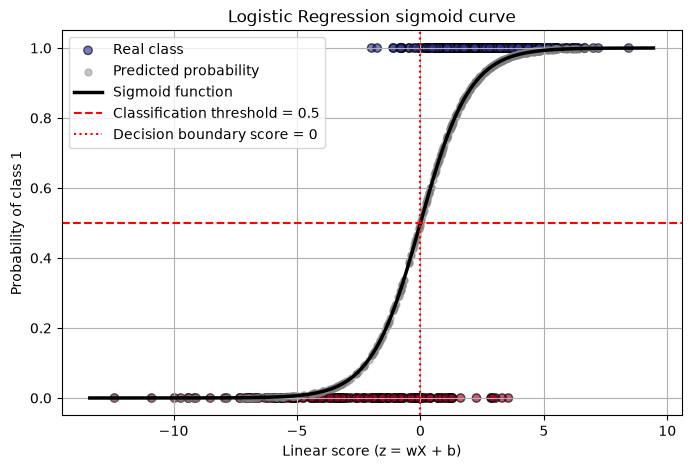

In [36]:
log_reg = LogisticRegression(random_state=42)

log_reg.fit(X_train_scaled, y_train)

y_test_pred_log = log_reg.predict(X_test_scaled)

print("Logistic Regression trained successfully.")


# Logistic Regression first computes a linear score and then maps it to probability with sigmoid.
logit_scores = log_reg.decision_function(X_train_scaled)
probabilities = log_reg.predict_proba(X_train_scaled)[:, 1]

score_grid = np.linspace(
    logit_scores.min() - 1,
    logit_scores.max() + 1,
    300
)
sigmoid_curve = 1 / (1 + np.exp(-score_grid))

plt.figure(figsize=(8, 5))
plt.scatter(
    logit_scores,
    y_train,
    c=y_train,
    cmap=plt.cm.RdYlBu,
    edgecolors='k',
    alpha=0.65,
    label='Real class'
)
plt.scatter(
    logit_scores,
    probabilities,
    color='gray',
    alpha=0.45,
    s=25,
    label='Predicted probability'
)
plt.plot(
    score_grid,
    sigmoid_curve,
    color='black',
    linewidth=2.5,
    label='Sigmoid function'
)
plt.axhline(
    0.5,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Classification threshold = 0.5'
)
plt.axvline(
    0,
    color='red',
    linestyle=':',
    linewidth=1.5,
    label='Decision boundary score = 0'
)
plt.xlabel('Linear score (z = wX + b)')
plt.ylabel('Probability of class 1')
plt.title('Logistic Regression sigmoid curve')
plt.legend()
plt.grid(True)
plt.show()


## 7. Support Vector Machine

### D1. What does the SVM attempt to determine between the two classes?
A linear SVM attempts to find the **hyperplane that separates the two classes while maximizing the margin** between the closest points of each class.

### D2. How is the SVM approach conceptually different from Logistic Regression?
Logistic Regression models the probability of belonging to a class using the sigmoid function and optimizes a log-loss objective. SVM focuses directly on finding a separating boundary with the largest possible margin, commonly using hinge loss, and it does not naturally produce probabilities.


In [37]:
svm_lin = SVC(
    kernel='linear',
    random_state=42
)

svm_lin.fit(X_train_scaled, y_train)

y_test_pred_svm = svm_lin.predict(X_test_scaled)

print("Linear SVM trained successfully.")

Linear SVM trained successfully.


## 8. Hard Margin vs Soft Margin

**Hard margin** tries to separate the classes without allowing margin violations. It works best when the data is perfectly linearly separable, but it can be too strict when the dataset contains noise or outliers.

**Soft margin** allows some points to fall inside the margin or even be misclassified. The parameter `C` controls this trade-off: a larger `C` penalizes violations more strongly, while a smaller `C` allows a wider and more tolerant margin.


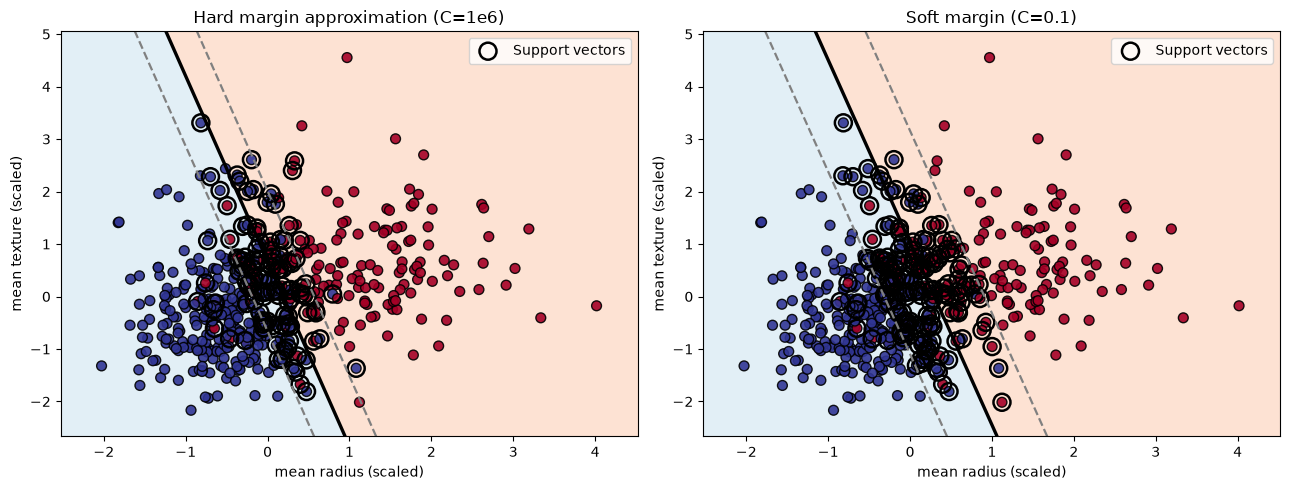

In [38]:
svm_hard_margin = SVC(
    kernel='linear',
    C=1e6,
    random_state=42
)

svm_soft_margin = SVC(
    kernel='linear',
    C=0.1,
    random_state=42
)

svm_hard_margin.fit(X_train_scaled, y_train)
svm_soft_margin.fit(X_train_scaled, y_train)


def plot_svm_margin(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    decision_values = model.decision_function(grid).reshape(xx.shape)

    ax.contourf(
        xx,
        yy,
        decision_values > 0,
        alpha=0.25,
        cmap=plt.cm.RdYlBu
    )

    ax.contour(
        xx,
        yy,
        decision_values,
        levels=[-1, 0, 1],
        colors=['gray', 'black', 'gray'],
        linestyles=['--', '-', '--'],
        linewidths=[1.6, 2.4, 1.6]
    )

    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=plt.cm.RdYlBu,
        edgecolors='k',
        s=50,
        alpha=0.9
    )

    ax.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=150,
        facecolors='none',
        edgecolors='black',
        linewidths=1.8,
        label='Support vectors'
    )

    ax.set_xlabel(feature1 + ' (scaled)')
    ax.set_ylabel(feature2 + ' (scaled)')
    ax.set_title(title)
    ax.legend(loc='best')


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_svm_margin(
    svm_hard_margin,
    X_train_scaled,
    y_train,
    'Hard margin approximation (C=1e6)',
    axes[0]
)

plot_svm_margin(
    svm_soft_margin,
    X_train_scaled,
    y_train,
    'Soft margin (C=0.1)',
    axes[1]
)

plt.tight_layout()
plt.show()


## 9. Decision boundary visualization

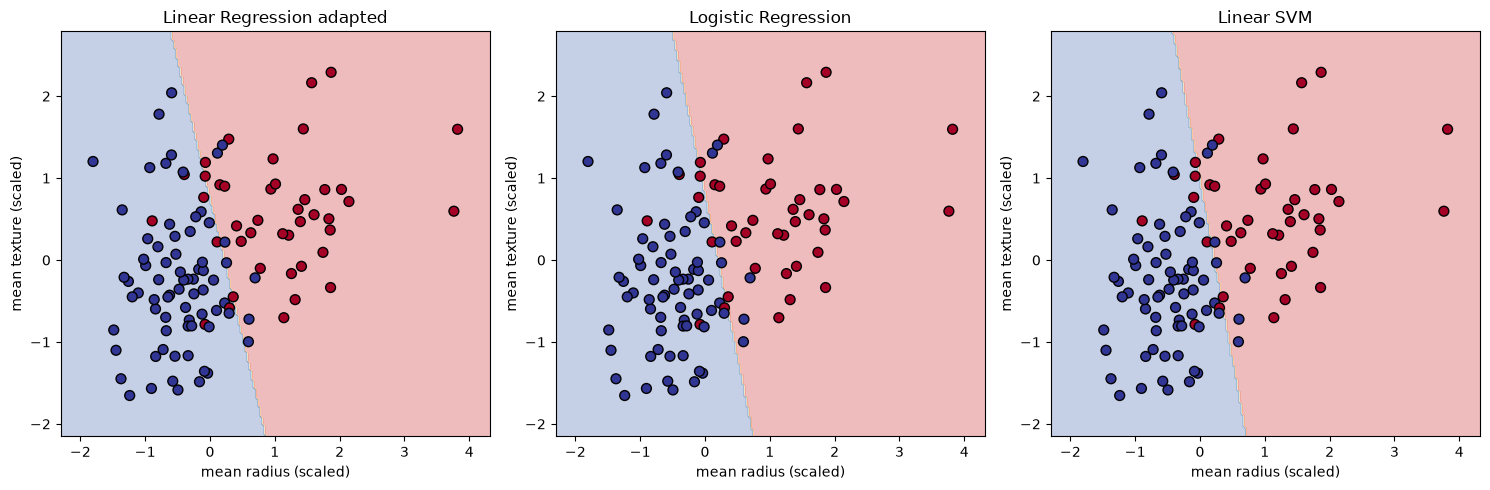

In [39]:
def plot_decision_boundary(
    model,
    X,
    y,
    title,
    ax,
    is_linear_scratch=False,
    threshold=None
):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    if is_linear_scratch:
        Z = model.predict(grid)
        Z = (Z >= threshold).astype(int)
    else:
        Z = model.predict(grid)

    Z = Z.reshape(xx.shape)

    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap=plt.cm.RdYlBu
    )

    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=plt.cm.RdYlBu,
        edgecolors='k',
        s=50
    )

    ax.set_xlabel(feature1 + ' (scaled)')
    ax.set_ylabel(feature2 + ' (scaled)')
    ax.set_title(title)

    return ax


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_decision_boundary(
    lr_model,
    X_test_scaled,
    y_test,
    'Linear Regression adapted',
    axes[0],
    is_linear_scratch=True,
    threshold=best_threshold
)

plot_decision_boundary(
    log_reg,
    X_test_scaled,
    y_test,
    'Logistic Regression',
    axes[1]
)

plot_decision_boundary(
    svm_lin,
    X_test_scaled,
    y_test,
    'Linear SVM',
    axes[2]
)

plt.tight_layout()
plt.show()

## 10. Model evaluation

For this experiment, the positive class is:

**Class 1 = Benign**

The following metrics are calculated using the same testing subset:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix


In [40]:
models = {
    'Linear Regression': y_test_pred_lr,
    'Logistic Regression': y_test_pred_log,
    'SVM': y_test_pred_svm
}

results = []

for name, pred in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-score': f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

print("Positive class = 1 (Benign)")
display(results_df.round(4))

Positive class = 1 (Benign)


,Model,Accuracy,Precision,Recall,F1-score
0,Linear Regression,0.8860,0.9155,0.9028,0.9091
1,Logistic Regression,0.8772,0.9028,0.9028,0.9028
2,SVM,0.8684,0.8904,0.9028,0.8966


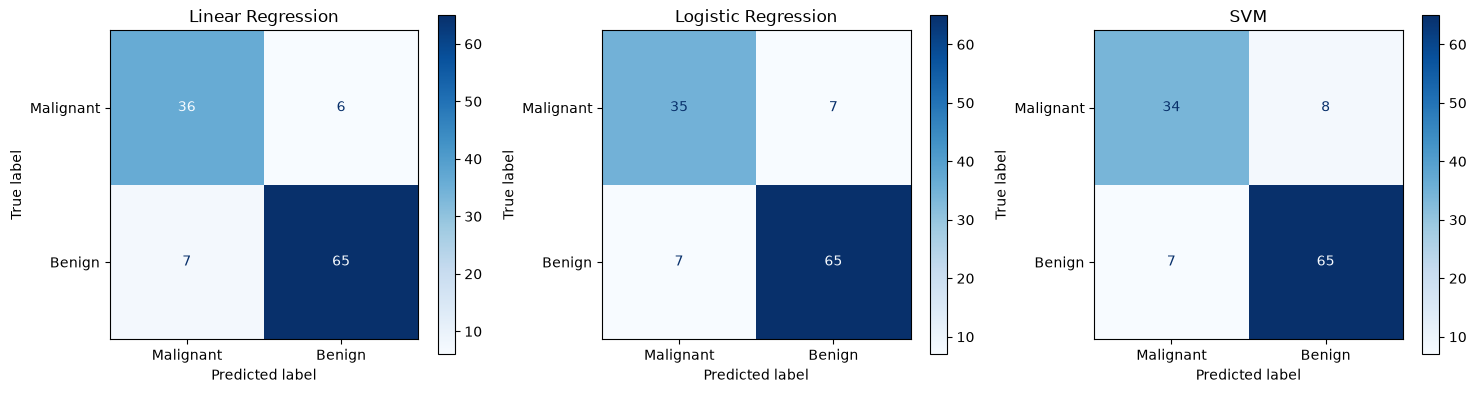

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Malignant', 'Benign']
    )

    disp.plot(
        ax=axes[idx],
        cmap='Blues',
        values_format='d'
    )

    axes[idx].set_title(name)

plt.tight_layout()
plt.show()

## 11. Model comparison

The three algorithms are evaluated on exactly the same test samples, allowing a direct comparison.

### Visual comparison
All three original approaches produce **linear decision boundaries**, but their location and orientation are not identical because each method uses a different optimization criterion.

- **Linear Regression** was originally designed to predict continuous values. It can be adapted to binary classification using a threshold, but its outputs are not probabilities and are not naturally restricted to `[0, 1]`.
- **Logistic Regression** is specifically designed for classification and models class probability through the sigmoid function.
- **Linear SVM** focuses on finding a separating hyperplane that maximizes the margin between the two classes.

### Metric comparison
The table above provides Accuracy, Precision, Recall, and F1-score for each model. The best model depends on the metric considered, so performance should not be judged using Accuracy alone.


In [42]:
best_accuracy_row = results_df.loc[results_df['Accuracy'].idxmax()]
best_f1_row = results_df.loc[results_df['F1-score'].idxmax()]

print(
    f"Highest Accuracy: {best_accuracy_row['Model']} "
    f"({best_accuracy_row['Accuracy']:.4f})"
)

print(
    f"Highest F1-score: {best_f1_row['Model']} "
    f"({best_f1_row['F1-score']:.4f})"
)

Highest Accuracy: Linear Regression (0.8860)
Highest F1-score: Linear Regression (0.9091)


## 12. Further exploration — SVM with RBF kernel and different C values

The laboratory asks for at least one modification to the original experiment.  
Here, two modifications are explored simultaneously:

1. Change the SVM kernel from `linear` to `rbf`.
2. Test different values of `C`: `0.1`, `1`, and `10`.

The RBF kernel can create non-linear decision boundaries.

The parameter `C` controls the trade-off between:
- obtaining a wider margin, and
- penalizing classification errors.

A smaller `C` generally tolerates more classification errors, while a larger `C` penalizes them more strongly.


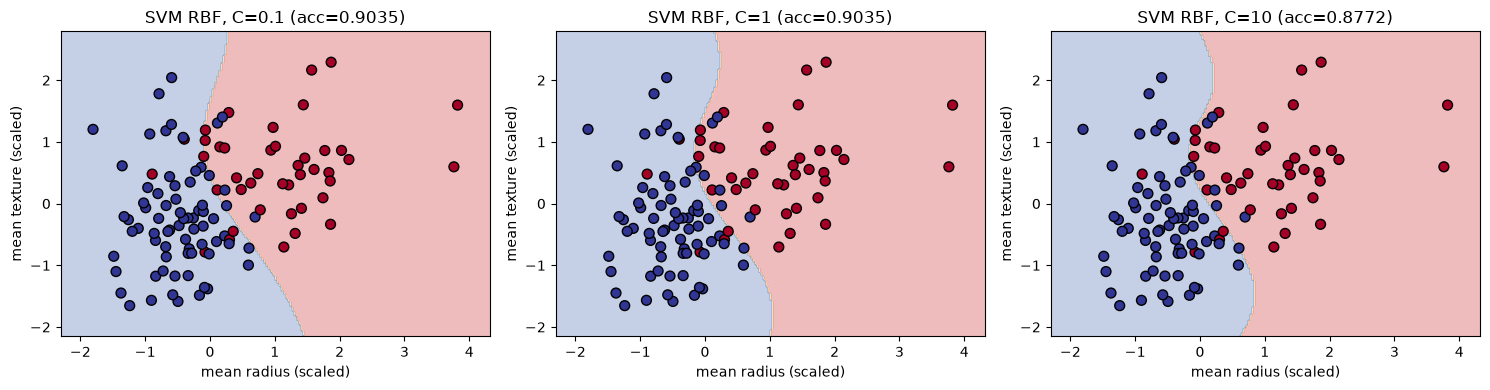

,C,Accuracy,F1-score
0,0.1,0.9035,0.9241
1,1.0,0.9035,0.9231
2,10.0,0.8772,0.9014


In [43]:
Cs = [0.1, 1, 10]

rbf_results = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, C in enumerate(Cs):
    svm_rbf = SVC(
        kernel='rbf',
        C=C,
        random_state=42
    )

    svm_rbf.fit(X_train_scaled, y_train)

    y_pred = svm_rbf.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    rbf_results.append({
        'C': C,
        'Accuracy': acc,
        'F1-score': f1
    })

    plot_decision_boundary(
        svm_rbf,
        X_test_scaled,
        y_test,
        f'SVM RBF, C={C} (acc={acc:.4f})',
        axes[i]
    )

plt.tight_layout()
plt.show()

rbf_results_df = pd.DataFrame(rbf_results)
display(rbf_results_df.round(4))

## Final conclusion

This experiment shows that different mathematical approaches can solve the same binary classification problem in different ways.

Linear Regression can be converted into a classifier through a threshold, but this is an adaptation of a regression technique. Logistic Regression and SVM are naturally designed for classification.

The comparison of decision boundaries and test metrics demonstrates why using the same dataset, preprocessing, training samples, and testing samples is essential for a fair comparison.

The additional RBF experiment also shows that changing the kernel and the value of `C` can modify both the shape of the decision boundary and model performance.
